In [1]:
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from einops import rearrange
import requests
import io
import json
from functools import reduce
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
import mediapy as media
import numpy as np
#from visualization_tools import game_coord_to_pixel_coord

In [11]:
run_dir = Path('runs/trajectories/vanilla_ppo') # Path('baselines/session_ebdfe818')
# original session_e41c9eff, main session_4da05e87, extra session_e1b6d2dc

In [12]:
def path_to_run(pth):
    df = pd.read_csv(pth, compression='gzip')
    df = df[df['map'] != 'map'].copy()
    return df

In [13]:
all_runs = [path_to_run(pth) for pth in tqdm(sorted(run_dir.glob('agent_stats_*.csv.gz')))]

100%|██████████| 48/48 [01:47<00:00,  2.23s/it]


In [15]:
len(all_runs)

48

In [16]:
len(all_runs[0])

1146880

In [18]:
poke_id_to_name = {
    177: "Squirtle",
    255: "None",
    0: "None",
    165: "Rattata",
    36: "Pidgey",
    179: "Wartortle",
    150: "Pidgeotto",
    112: "Weedle",
    113: "Kakuna",
    114: "Beedrill",
    133: "Magikarp",
    169: "Geodude",
    107: "Zubat",
    109: "Paras",
    100: "Jigglypuff",
    84: "Pikachu",
    123: "Caterpie",
    124: "Metapod",
    4: "Clefairy",
    5: "Spearow",
    15: "Nidoran♀"
}
valid_list = [name for name in poke_id_to_name.values() if name != 'None']
valid_list

['Squirtle',
 'Rattata',
 'Pidgey',
 'Wartortle',
 'Pidgeotto',
 'Weedle',
 'Kakuna',
 'Beedrill',
 'Magikarp',
 'Geodude',
 'Zubat',
 'Paras',
 'Jigglypuff',
 'Pikachu',
 'Caterpie',
 'Metapod',
 'Clefairy',
 'Spearow',
 'Nidoran♀']

In [19]:
poke_colors = {
 'Squirtle': (116, 196, 215),
 'Rattata': (157, 134, 162),
 'Pidgey': (190, 157, 119),
 'Wartortle': (80, 156, 214),
 'Pidgeotto': (233, 128, 118),
 'Weedle': (190, 150, 81),
 'Kakuna': (226, 200, 123),
 'Magikarp': (244, 119, 87),
 'Geodude': (176, 176, 176),
 'Zubat': (157, 82, 175),
 'Paras': (241, 171, 100),
 'Jigglypuff': (255, 200, 220),
 'Pikachu': (252, 244, 107),
 'Metapod': (162, 222, 80),
 'Clefairy': (218, 165, 183),
 'Spearow': (163, 75, 71),
 'Nidoran♀': (163, 167, 205),
 'Beedrill': (255,211,109),
 'Caterpie': (125, 206, 104)
}

In [21]:
all_poke_counts = []
missing_poke = set()

for run_df in tqdm(all_runs):
    p_counts = {p: 0 for p in valid_list}
    caught_pokes = set()

    for step in run_df['ptypes'].dropna():
        party = json.loads(step)
        for p in party:
            if p in poke_id_to_name:
                pname = poke_id_to_name[p]
                if pname != 'None':
                    caught_pokes.add(pname)
            elif p not in missing_poke:
                missing_poke.add(p)
                print(f'missing poke id: {p}')

    for p in caught_pokes:
        p_counts[p] += 1

    all_poke_counts.append(p_counts)
        

  0%|          | 0/48 [00:00<?, ?it/s]

missing poke id: 176
missing poke id: 153


 69%|██████▉   | 33/48 [02:45<01:13,  4.87s/it]

missing poke id: 178


100%|██████████| 48/48 [04:00<00:00,  5.01s/it]


In [22]:
all_poke_counts

[{'Squirtle': 0,
  'Rattata': 0,
  'Pidgey': 0,
  'Wartortle': 0,
  'Pidgeotto': 0,
  'Weedle': 0,
  'Kakuna': 0,
  'Beedrill': 0,
  'Magikarp': 0,
  'Geodude': 0,
  'Zubat': 0,
  'Paras': 0,
  'Jigglypuff': 0,
  'Pikachu': 0,
  'Caterpie': 0,
  'Metapod': 0,
  'Clefairy': 0,
  'Spearow': 0,
  'Nidoran♀': 0},
 {'Squirtle': 1,
  'Rattata': 0,
  'Pidgey': 0,
  'Wartortle': 0,
  'Pidgeotto': 0,
  'Weedle': 0,
  'Kakuna': 0,
  'Beedrill': 0,
  'Magikarp': 0,
  'Geodude': 0,
  'Zubat': 0,
  'Paras': 0,
  'Jigglypuff': 0,
  'Pikachu': 0,
  'Caterpie': 0,
  'Metapod': 0,
  'Clefairy': 0,
  'Spearow': 0,
  'Nidoran♀': 0},
 {'Squirtle': 1,
  'Rattata': 0,
  'Pidgey': 0,
  'Wartortle': 0,
  'Pidgeotto': 0,
  'Weedle': 0,
  'Kakuna': 0,
  'Beedrill': 0,
  'Magikarp': 0,
  'Geodude': 0,
  'Zubat': 0,
  'Paras': 0,
  'Jigglypuff': 0,
  'Pikachu': 0,
  'Caterpie': 0,
  'Metapod': 0,
  'Clefairy': 0,
  'Spearow': 0,
  'Nidoran♀': 0},
 {'Squirtle': 1,
  'Rattata': 0,
  'Pidgey': 0,
  'Wartortle': 0,
 

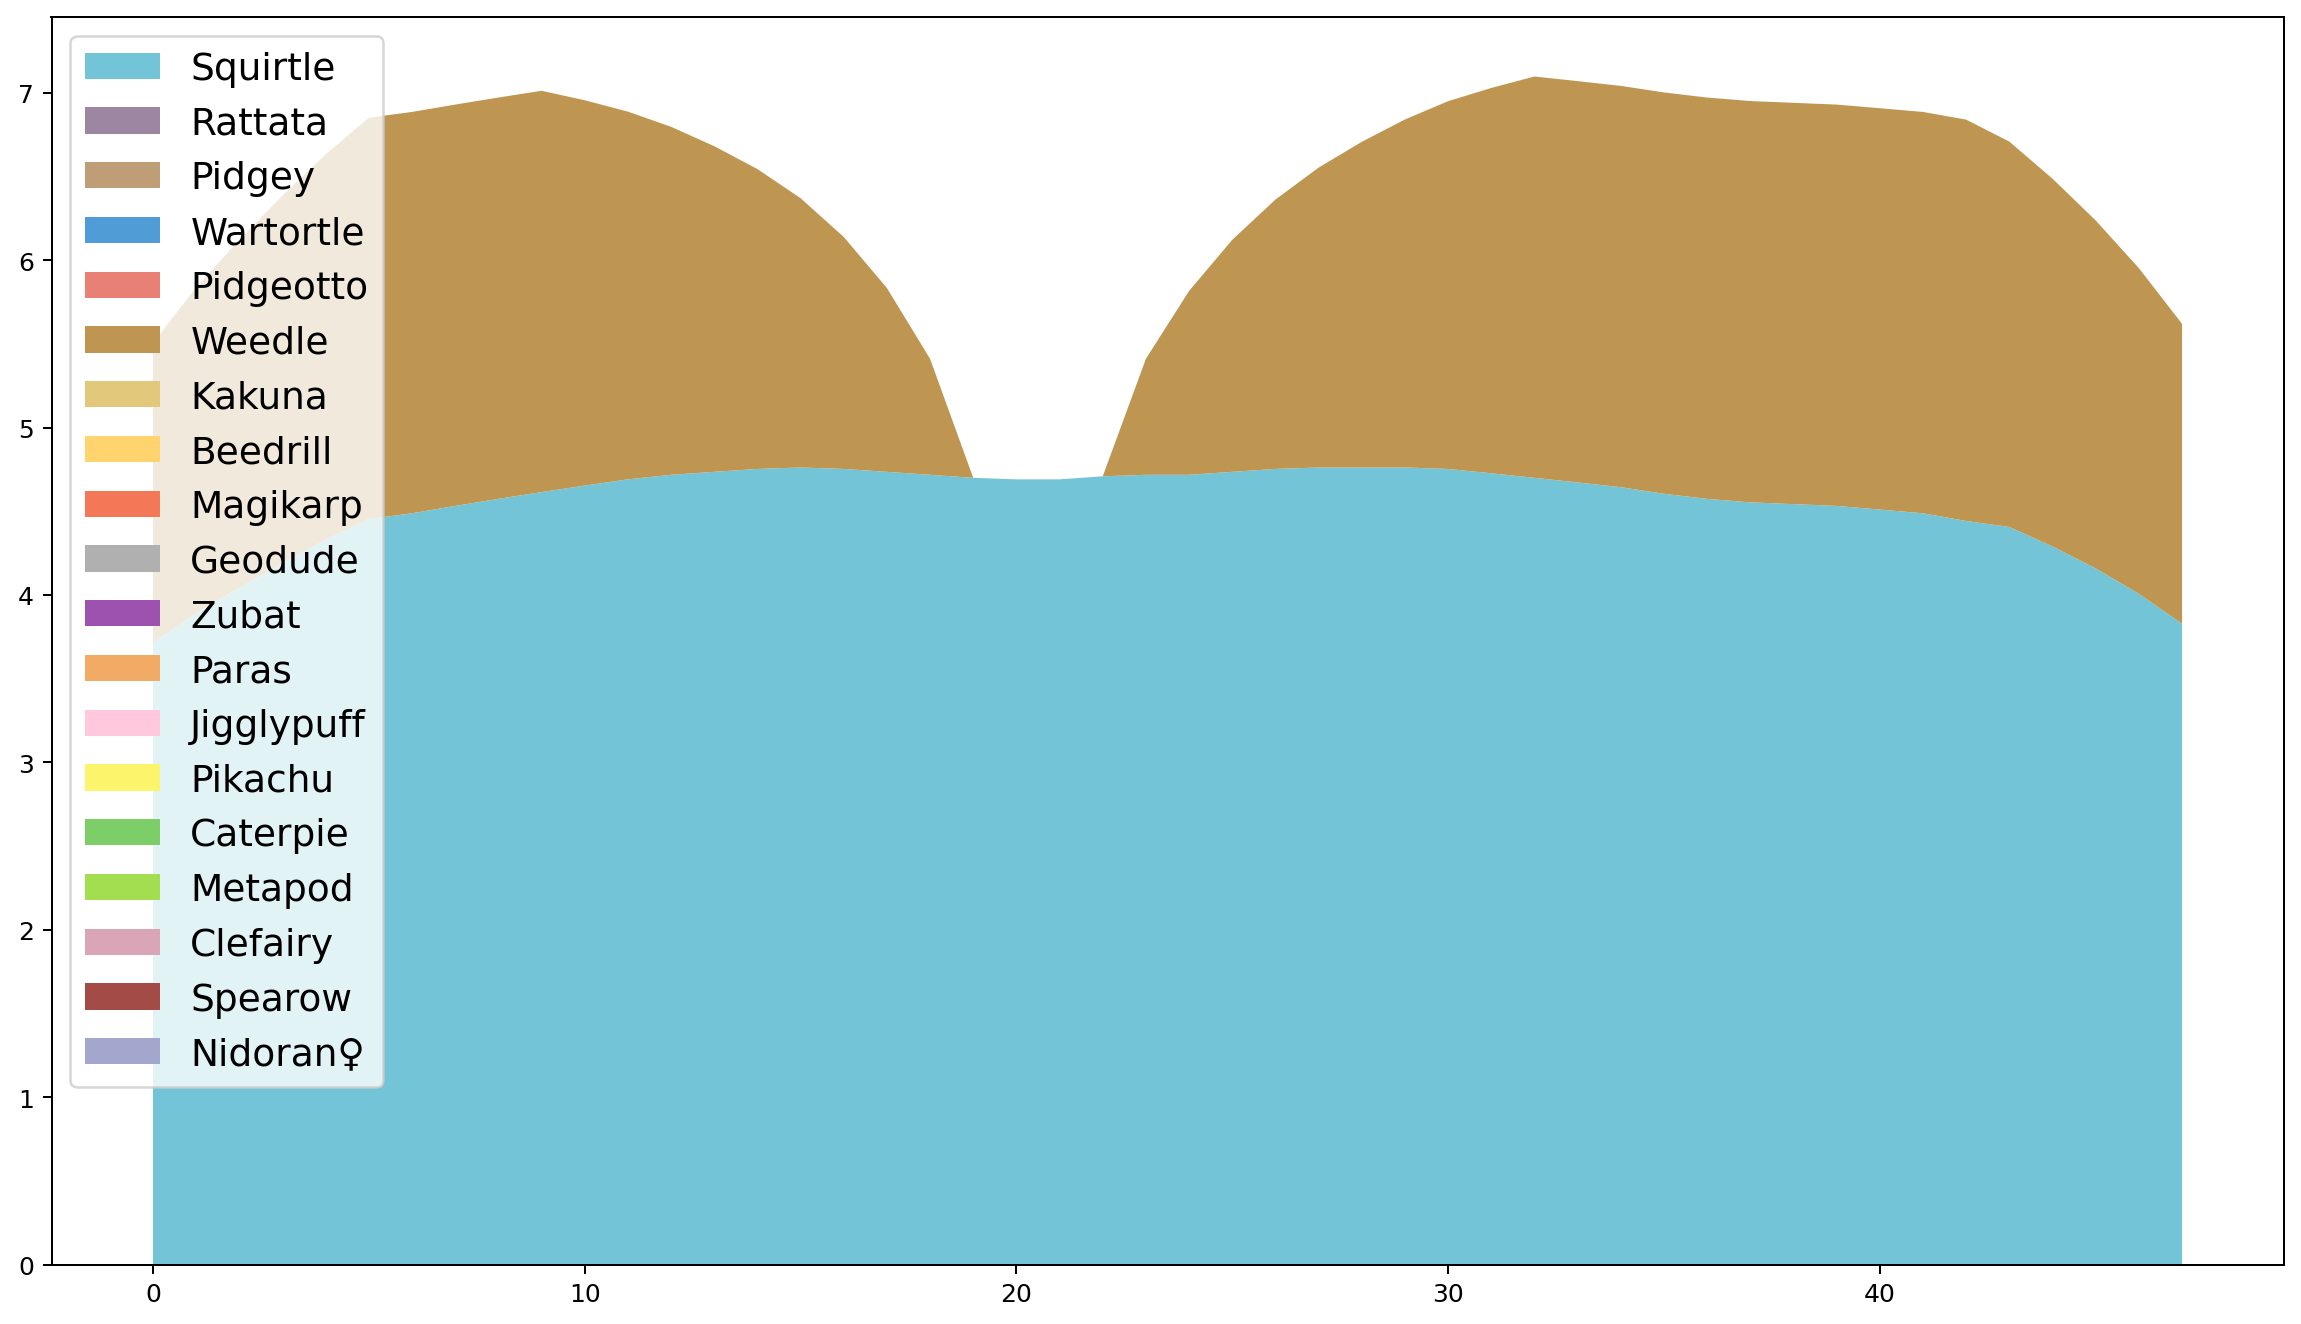

In [25]:
steps = len(all_poke_counts)
x = range(steps)
raw_counts = np.array(list(zip(*[list(counts.values()) for counts in all_poke_counts])))
raw_counts = [np.convolve(rc, np.ones(20), mode='same') for rc in raw_counts]
raw_counts = [np.log(1+np.convolve(rc, np.ones(10), mode='same')) for rc in raw_counts]
plt.figure(figsize=(16, 9), dpi=180)
# cols = plt.cm.nipy_spectral(np.linspace(0, 1, len(valid_list)))
# plt.stackplot(x, *raw_counts, labels=valid_list, colors=cols)
cols = [tuple(np.array(poke_colors[p]) / 255.0) for p in valid_list]
plt.stackplot(x, *raw_counts, labels=valid_list, colors=cols)
plt.legend(loc='upper left', prop={'size': 15})

In [31]:
base_stats = {
    'pcount': 0,
    'total_levels': 0,
    'deaths': 0,
    'event': 0,
    'healr': 0,
    'badge': 0
}

In [32]:
# def df_to_numpy(df):
    # # load levels and sum
    # df['total_levels'] = df['levels'].map(lambda x: sum(json.loads(x)))
    # #df = df.drop(columns=['levels', 'ptypes', 'Unnamed: 0', 'step', ])
    # #df['gcoords'] = df.apply(
    # #    lambda r: fastish(r['x'], r['y'], r['map'], 4000), axis=1)
    # #df['gx'] = df['gcoords'].map(lambda c: c[0])
    # #df['gy'] = df['gcoords'].map(lambda c: c[1])
    # # select only relevant stats and convert all to floats
    # return df[base_stats.keys()].applymap(lambda v: float(v)).to_numpy()

def df_to_numpy(df):
    df = df.copy()
    df['total_levels'] = df['levels'].map(lambda x: sum(json.loads(x)))
    return df[list(base_stats.keys())].astype(float).to_numpy()

In [33]:
name_to_idx = {name:idx for idx, name in enumerate(base_stats.keys())}
name_to_idx

{'pcount': 0,
 'total_levels': 1,
 'deaths': 2,
 'event': 3,
 'healr': 4,
 'badge': 5}

In [34]:
big_dat = np.array([df_to_numpy(run_df) for run_df in tqdm(all_runs)], dtype=float)


100%|██████████| 48/48 [02:51<00:00,  3.57s/it]


In [35]:
big_dat.shape

(48, 1146880, 6)

In [38]:
big_dat[:, :, 0].mean(axis=1).shape

(48,)

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

the_dat = 'total_levels'
steps = 100
start_step = 130
stride = 500  # downsample to keep plotting reasonable

plot_dat = big_dat[:, ::stride, name_to_idx[the_dat]].copy()
for j in range(len(plot_dat)):
    plot_dat[j] = gaussian_filter(plot_dat[j], 20.0, mode='nearest')

out_path = f"{the_dat}.mp4"
fps = 20
writer = None

for i in tqdm(np.geomspace(start_step, plot_dat.shape[1], num=steps)):
    i = int(i)

    fig = plt.figure(figsize=(16, 9), dpi=120)
    for idx, dat in enumerate(plot_dat[:, :i]):
        plt.plot(dat, color=plt.cm.jet(idx / plot_dat.shape[0]))

    plt.title(the_dat)
    plt.xlabel('game actions', fontsize=14)
    plt.ylabel(the_dat, fontsize=14)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    w, h = fig.canvas.get_width_height()
    frame = buf.reshape((h, w, 3))
    frame = np.ascontiguousarray(frame.astype(np.uint8))

    if writer is None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
        if not writer.isOpened():
            raise RuntimeError(f"Could not open video writer for {out_path}")

    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    plt.close(fig)

if writer is not None:
    writer.release()

C:\Users\jared\AppData\Local\Temp\ipykernel_24688\1436632649.py:32: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
100%|██████████| 100/100 [00:22<00:00,  4.46it/s]


In [42]:
the_dat = 'deaths'
steps = 100
start_step = 20
stride = 500  # downsample for speed / stability

plot_dat = big_dat[:, ::stride, name_to_idx[the_dat]].copy()
for j in range(len(plot_dat)):
    plot_dat[j] = gaussian_filter(plot_dat[j], 20.0, mode='nearest')

out_path = f"{the_dat}.mp4"
fps = 20
writer = None

for i in tqdm(np.geomspace(start_step, plot_dat.shape[1], num=steps)):
    i = int(i)

    fig = plt.figure(figsize=(16, 9), dpi=120)
    for idx, dat in enumerate(plot_dat[:, :i]):
        plt.plot(dat, color=plt.cm.turbo(idx / plot_dat.shape[0]))

    plt.title(the_dat)
    plt.xlabel('game actions', fontsize=14)
    plt.ylabel(the_dat, fontsize=14)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    w, h = fig.canvas.get_width_height()
    frame = buf.reshape((h, w, 3))
    frame = np.ascontiguousarray(frame.astype(np.uint8))

    if writer is None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
        if not writer.isOpened():
            raise RuntimeError(f"Could not open video writer for {out_path}")

    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    plt.close(fig)

if writer is not None:
    writer.release()

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\jared\AppData\Local\Temp\ipykernel_24688\1591446405.py:26: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
100%|██████████| 100/100 [00:23<00:00,  4.29it/s]


In [43]:
# flipped so we can see progression differently
the_dat = 'total_levels'
steps = 10
start_step = 20
stride = 500  # downsample for speed / stability

plot_dat = big_dat[:, ::stride, name_to_idx[the_dat]].copy()
for j in range(len(plot_dat)):
    plot_dat[j] = gaussian_filter(plot_dat[j], 20.0, mode='nearest')

out_path = f"{the_dat}.mp4"
fps = 20
writer = None

for i in tqdm(np.geomspace(start_step, plot_dat.shape[1], num=steps)):
    i = int(i)

    fig = plt.figure(figsize=(16, 9), dpi=120)
    for idx, dat in enumerate(plot_dat[:, :i]):
        plt.plot(dat, color=plt.cm.turbo(idx / plot_dat.shape[0]))

    plt.title(the_dat)
    plt.xlabel('game actions', fontsize=14)
    plt.ylabel(the_dat, fontsize=14)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    w, h = fig.canvas.get_width_height()
    frame = buf.reshape((h, w, 3))
    frame = np.ascontiguousarray(frame.astype(np.uint8))

    if writer is None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
        if not writer.isOpened():
            raise RuntimeError(f"Could not open video writer for {out_path}")

    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    plt.close(fig)

if writer is not None:
    writer.release()

  0%|          | 0/10 [00:00<?, ?it/s]C:\Users\jared\AppData\Local\Temp\ipykernel_24688\1751547859.py:27: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
100%|██████████| 10/10 [00:01<00:00,  5.41it/s]


In [44]:
all_poke_counts[0]

{'Squirtle': 0,
 'Rattata': 0,
 'Pidgey': 0,
 'Wartortle': 0,
 'Pidgeotto': 0,
 'Weedle': 0,
 'Kakuna': 0,
 'Beedrill': 0,
 'Magikarp': 0,
 'Geodude': 0,
 'Zubat': 0,
 'Paras': 0,
 'Jigglypuff': 0,
 'Pikachu': 0,
 'Caterpie': 0,
 'Metapod': 0,
 'Clefairy': 0,
 'Spearow': 0,
 'Nidoran♀': 0}

In [45]:
mix_val = 0.1

out_path = 'poke_pie.mp4'
fps = 20
writer = None

vals = {p: 0 for p in valid_list}

for cur_poke in tqdm(all_poke_counts):
    fig = plt.figure(figsize=(16, 9), dpi=120)

    # update smoothed counts
    for name, count in vals.items():
        cc = cur_poke.get(name, 0)
        vals[name] = count * (1 - mix_val) + cc * mix_val

    poke_filtered = {name: count for name, count in vals.items() if count > 0}

    if len(poke_filtered) == 0:
        plt.close(fig)
        continue

    plt.pie(
        poke_filtered.values(),
        labels=poke_filtered.keys(),
        colors=[
            tuple(np.array(poke_colors.get(p, (128, 128, 128))) / 255.0)
            for p in poke_filtered.keys()
        ],
        autopct='%1.1f%%',
        shadow=False,
        startangle=90
    )

    plt.axis('equal')

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    w, h = fig.canvas.get_width_height()
    frame = buf.reshape((h, w, 3))
    frame = np.ascontiguousarray(frame.astype(np.uint8))

    if writer is None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
        if not writer.isOpened():
            raise RuntimeError(f"Could not open video writer for {out_path}")

    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    plt.close(fig)

if writer is not None:
    writer.release()

  0%|          | 0/48 [00:00<?, ?it/s]C:\Users\jared\AppData\Local\Temp\ipykernel_24688\1852548076.py:38: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
100%|██████████| 48/48 [00:06<00:00,  7.60it/s]


In [46]:
my_df = pd.DataFrame(all_poke_counts).transpose()#.to_csv('cool_poke_data.csv') 
my_df

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
Squirtle,0,1,1,1,1,1,1,0,1,1,...,1,0,0,0,1,1,0,1,0,1
Rattata,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pidgey,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Wartortle,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pidgeotto,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Weedle,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Kakuna,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Beedrill,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Magikarp,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Geodude,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
new_df = pd.DataFrame()
mg = 4
for c in range(len(my_df.columns)//mg):
    new_df[c*3] = (my_df[c*mg] + my_df[c*mg+1] + my_df[c*mg+2] + my_df[c*mg+3]) / (mg*5/100)
new_df = new_df.copy()
new_df.to_csv('cool_poke_data.csv') 

In [48]:
# total pokemon caught!
tot_caught = 0
for run in all_poke_counts:
    for name,count in run.items():
        if name != 'Squirtle':
            tot_caught += count
tot_caught

2

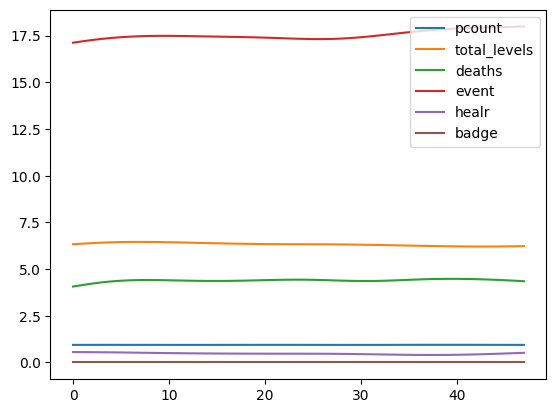

In [50]:
for name in name_to_idx.keys():
    if name == 'frames':
        continue
    plt.plot(
        gaussian_filter(
            big_dat[:, :, name_to_idx[name]].mean(axis=1)
        , 5.0, mode='nearest'),
        label=name
    )
    plt.legend()

In [60]:
stats = []

for run_df in all_runs:
    final = run_df.iloc[-1]

    stat = {
        'events': float(final['event']),
        'party_xp': float(sum(json.loads(final['levels']))),
        'levels': float(sum(json.loads(final['levels']))),
        'op_level': 0,      # not tracked anymore
        'op_poke': 0,       # not tracked anymore
        'seen_poke': float(final['coord_count']),
        'explore': float(final['coord_count'])
    }

    stats.append(stat)

stats

[{'events': 34.0,
  'party_xp': 11.0,
  'levels': 11.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 2218.0,
  'explore': 2218.0},
 {'events': 30.0,
  'party_xp': 6.0,
  'levels': 6.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1338.0,
  'explore': 1338.0},
 {'events': 30.0,
  'party_xp': 5.0,
  'levels': 5.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1431.0,
  'explore': 1431.0},
 {'events': 30.0,
  'party_xp': 7.0,
  'levels': 7.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1786.0,
  'explore': 1786.0},
 {'events': 30.0,
  'party_xp': 6.0,
  'levels': 6.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1591.0,
  'explore': 1591.0},
 {'events': 18.0,
  'party_xp': 9.0,
  'levels': 9.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1653.0,
  'explore': 1653.0},
 {'events': 30.0,
  'party_xp': 6.0,
  'levels': 6.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1597.0,
  'explore': 1597.0},
 {'events': 30.0,
  'party_xp': 7.0,
  'levels': 7.0,
  'op_level': 0,
  '

In [61]:
stats

[{'events': 34.0,
  'party_xp': 11.0,
  'levels': 11.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 2218.0,
  'explore': 2218.0},
 {'events': 30.0,
  'party_xp': 6.0,
  'levels': 6.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1338.0,
  'explore': 1338.0},
 {'events': 30.0,
  'party_xp': 5.0,
  'levels': 5.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1431.0,
  'explore': 1431.0},
 {'events': 30.0,
  'party_xp': 7.0,
  'levels': 7.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1786.0,
  'explore': 1786.0},
 {'events': 30.0,
  'party_xp': 6.0,
  'levels': 6.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1591.0,
  'explore': 1591.0},
 {'events': 18.0,
  'party_xp': 9.0,
  'levels': 9.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1653.0,
  'explore': 1653.0},
 {'events': 30.0,
  'party_xp': 6.0,
  'levels': 6.0,
  'op_level': 0,
  'op_poke': 0,
  'seen_poke': 1597.0,
  'explore': 1597.0},
 {'events': 30.0,
  'party_xp': 7.0,
  'levels': 7.0,
  'op_level': 0,
  '